[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/ner/02-bioclinicalbert-weighted.ipynb)

# Fine Tuning Bio_ClinicalBERT for Medical Named Entity Recognition (NER)

## Description
This notebook fine-tunes `emilyalsentzer/Bio_ClinicalBERT` on the `MedMentions-MTI881-NER` dataset to identify medical entities in clinical text.

Because Medical NER datasets suffer from heavy class imbalance (the vast majority of tokens are 'O' - Outside), I implement a custom `WeightedTrainer` that calculates exponential class penalties to allow the model to learn rare medical concepts without being overwhelmed by background text.

**To load this model from the Hub:**
```python
from transformers import pipeline

ner_pipe = pipeline("ner", model="alexd063/bio-clinicalbert-finetuned-medmentions-v1")
results = ner_pipe("Patient shows symptoms of acute appendicitis.")
print(results)

In [1]:
%%capture
!pip install transformers datasets evaluate seqeval accelerate torch numpy pandas matplotlib seaborn
!pip install --upgrade transformers

In [2]:
import os
# Suppress all tqdm/HuggingFace progress bars before any library is imported
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"] = "1"

In [3]:
import torch
import evaluate
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
from seqeval.metrics import classification_report
from huggingface_hub import notebook_login, whoami

In [4]:
import os
os.environ["TQDM_DISABLE"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets import disable_progress_bars
disable_progress_bars()

from huggingface_hub.utils import disable_progress_bars as hub_disable_progress_bars
hub_disable_progress_bars()

In [5]:
PUSH_TO_HUB = True  # Set to False to skip login and hub push

if PUSH_TO_HUB:
    notebook_login()

    # print(whoami())

In [6]:
import time
notebook_start_time = time.time()


## 1. Hyperparameters

* **Model (`Bio_ClinicalBERT`)**: Pre-trained on MIMIC-III clinical notes, this model has some knowledge of medical domain and terms, making it superior to standard BERT for this task.
* **Learning Rate (`6e-5`)**: Slightly higher than standard BERT fine-tuning (usually `2e-5`). Medical NER introduces many novel combinations and acronyms, which mandates a higher learning rate.
* **Scheduler (`Cosine` with `10% Warmup`)**: Warmup prevents catastrophic forgetting of the pre-trained weights by gradually increasing the learning rate, cosine decay smoothly fine-tunes the decision boundaries at the end of training.
* **Epochs & Early Stopping**: set to `20` to give the model time to converge on minority classes, but rely on an `EarlyStoppingCallback` (patience = 2) to stop training if validation (F1 score) stops improving, preventing overfitting.

In [7]:
class Config:
    MODEL_ID = "emilyalsentzer/Bio_ClinicalBERT"
    DATASET_ID = "Ben10x/MedMentions-MTI881-NER"
    HUB_REPO_ID = "alexd063/bio-clinicalbert-finetuned-medmentions-v1"

    MAX_LENGTH = 512 # max tokens, max for BERT
    BATCH_SIZE = 16
    EPOCHS = 20
    LEARNING_RATE = 6e-5
    WARMUP_RATIO = 0.10
    WEIGHT_DECAY = 0.01

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Config()

## 2. Data loading & preprocessing
Loads the `MedMentions` dataset, extracts the entity tags to build `label2id` mapping, and tokenizes the sequences.

Special tokens (`[CLS]`, `[SEP]`, and word sub-tokens) are mapped to `-100` so they are ignored by the CrossEntropy loss function.

In [8]:
dataset = load_dataset(config.DATASET_ID)

unique_tags = set()
for split in dataset.keys():
    for row in dataset[split]["ner_tags"]:
        unique_tags.update(row)

label_list = sorted(list(unique_tags))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_ID)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=config.MAX_LENGTH
    )

    labels = []
    for i, label_sequence in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Ignore special tokens
            if word_idx is None:
                label_ids.append(-100)
            # Label the first token of a given word
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label_sequence[word_idx]])
            # Ignore subsequent sub-tokens of the same word
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

## 3. Handling class imbalance using class weights & defining metrics
The dataset is heavily skewed towards the 'O' (Outside) label. Standard training may bias the model to predict 'O' for everything to achieve high accuracy.

To fix this, calculate an inverse frequency weight for each class while downweighting the 'O' class (`0.5`). This will result in class weights inversely proportional to the frequency of the respective class.

In [9]:
all_tags_flat = [tag for sublist in dataset['train']['ner_tags'] for tag in sublist]
tag_counts = pd.Series(all_tags_flat).value_counts()

num_classes = len(label_list)
total_samples = tag_counts.sum()

# class weights
class_weights_dict = {
    tag: np.round(np.exp(-(num_classes * count) / total_samples) * 100)
    for tag, count in tag_counts.items()
}
class_weights_dict['O'] = np.float64(0.5)

# order weights to match label2id
class_weights = [class_weights_dict.get(id2label[i], 1.0) for i in range(num_classes)]

print("Top 5 highest weights (Rarest classes):", sorted(class_weights, reverse=True)[:5])
print("Weight for 'O' class:", class_weights_dict.get('O'))

Top 5 highest weights (Rarest classes): [np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
Weight for 'O' class: 0.5


In [10]:
%%capture
# evaluation metrics
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (-100)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": np.round(results["overall_precision"], 3),
        "recall": np.round(results["overall_recall"], 3),
        "f1": np.round(results["overall_f1"], 3),
        "accuracy": np.round(results["overall_accuracy"], 3),
    }

## 4. Model initialization & training
To make use of overloaded class weights - inherit `Trainer` class.

In [11]:

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(config.DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights, ignore_index=-100)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./bio-clinicalbert-medmentions",
    per_device_train_batch_size=config.BATCH_SIZE,
    per_device_eval_batch_size=config.BATCH_SIZE,
    # ---------------------------------
    # training rate & length
    # ---------------------------------
    num_train_epochs=config.EPOCHS,
    learning_rate=config.LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=config.WARMUP_RATIO,
    weight_decay=config.WEIGHT_DECAY,
    # ---------------------------------
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    hub_model_id=config.HUB_REPO_ID if PUSH_TO_HUB else None
)

model = AutoModelForTokenClassification.from_pretrained(
    config.MODEL_ID,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    class_weights=class_weights,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

trainer.save_model("./bio-clinicalbert-medmentions-final")


{'loss': '3.873', 'grad_norm': '9.465', 'learning_rate': '1.023e-05', 'epoch': '0.3418'}
{'loss': '2.021', 'grad_norm': '10.64', 'learning_rate': '2.049e-05', 'epoch': '0.6835'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '1.299', 'eval_precision': '0.181', 'eval_recall': '0.441', 'eval_f1': '0.256', 'eval_accuracy': '0.609', 'eval_runtime': '5.819', 'eval_samples_per_second': '502.5', 'eval_steps_per_second': '31.45', 'epoch': '1'}
{'loss': '1.422', 'grad_norm': '6.253', 'learning_rate': '3.074e-05', 'epoch': '1.025'}
{'loss': '1.122', 'grad_norm': '6.026', 'learning_rate': '4.099e-05', 'epoch': '1.367'}
{'loss': '1.085', 'grad_norm': '4.791', 'learning_rate': '5.124e-05', 'epoch': '1.709'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '1.014', 'eval_precision': '0.23', 'eval_recall': '0.519', 'eval_f1': '0.318', 'eval_accuracy': '0.656', 'eval_runtime': '5.627', 'eval_samples_per_second': '519.7', 'eval_steps_per_second': '32.52', 'epoch': '2'}
{'loss': '0.9708', 'grad_norm': '9.505', 'learning_rate': '6e-05', 'epoch': '2.051'}
{'loss': '0.7277', 'grad_norm': '7.229', 'learning_rate': '5.993e-05', 'epoch': '2.392'}
{'loss': '0.7216', 'grad_norm': '11.86', 'learning_rate': '5.975e-05', 'epoch': '2.734'}


...

{'eval_loss': '2.575', 'eval_precision': '0.594', 'eval_recall': '0.709', 'eval_f1': '0.646', 'eval_accuracy': '0.875', 'eval_runtime': '5.596', 'eval_samples_per_second': '522.5', 'eval_steps_per_second': '32.7', 'epoch': '18'}
{'loss': '0.0116', 'grad_norm': '0.1464', 'learning_rate': '1.613e-06', 'epoch': '18.11'}
{'loss': '0.01087', 'grad_norm': '0.1718', 'learning_rate': '1.085e-06', 'epoch': '18.46'}
{'loss': '0.01088', 'grad_norm': '0.411', 'learning_rate': '6.596e-07', 'epoch': '18.8'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '2.583', 'eval_precision': '0.596', 'eval_recall': '0.712', 'eval_f1': '0.649', 'eval_accuracy': '0.876', 'eval_runtime': '5.555', 'eval_samples_per_second': '526.4', 'eval_steps_per_second': '32.94', 'epoch': '19'}
{'loss': '0.01143', 'grad_norm': '0.2671', 'learning_rate': '3.388e-07', 'epoch': '19.14'}
{'loss': '0.01043', 'grad_norm': '0.4758', 'learning_rate': '1.235e-07', 'epoch': '19.48'}
{'loss': '0.009871', 'grad_norm': '0.3798', 'learning_rate': '1.454e-08', 'epoch': '19.82'}


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '2.59', 'eval_precision': '0.595', 'eval_recall': '0.711', 'eval_f1': '0.648', 'eval_accuracy': '0.876', 'eval_runtime': '5.796', 'eval_samples_per_second': '504.5', 'eval_steps_per_second': '31.57', 'epoch': '20'}
{'train_runtime': '1607', 'train_samples_per_second': '291.3', 'train_steps_per_second': '18.21', 'train_loss': '0.3009', 'epoch': '20'}


## 5. Evaluation & metrics

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '2.696', 'eval_precision': '0.599', 'eval_recall': '0.714', 'eval_f1': '0.652', 'eval_accuracy': '0.877', 'eval_runtime': '5.516', 'eval_samples_per_second': '530.5', 'eval_steps_per_second': '33.18', 'epoch': '20'}

Test evaluation results
LOSS        : 2.6961
PRECISION   : 0.5990
RECALL      : 0.7140
F1          : 0.6520
ACCURACY    : 0.8770
RUNTIME     : 5.5157
SAMPLES_PER_SECOND: 530.4870
STEPS_PER_SECOND: 33.1780
EPOCH       : 20.0000



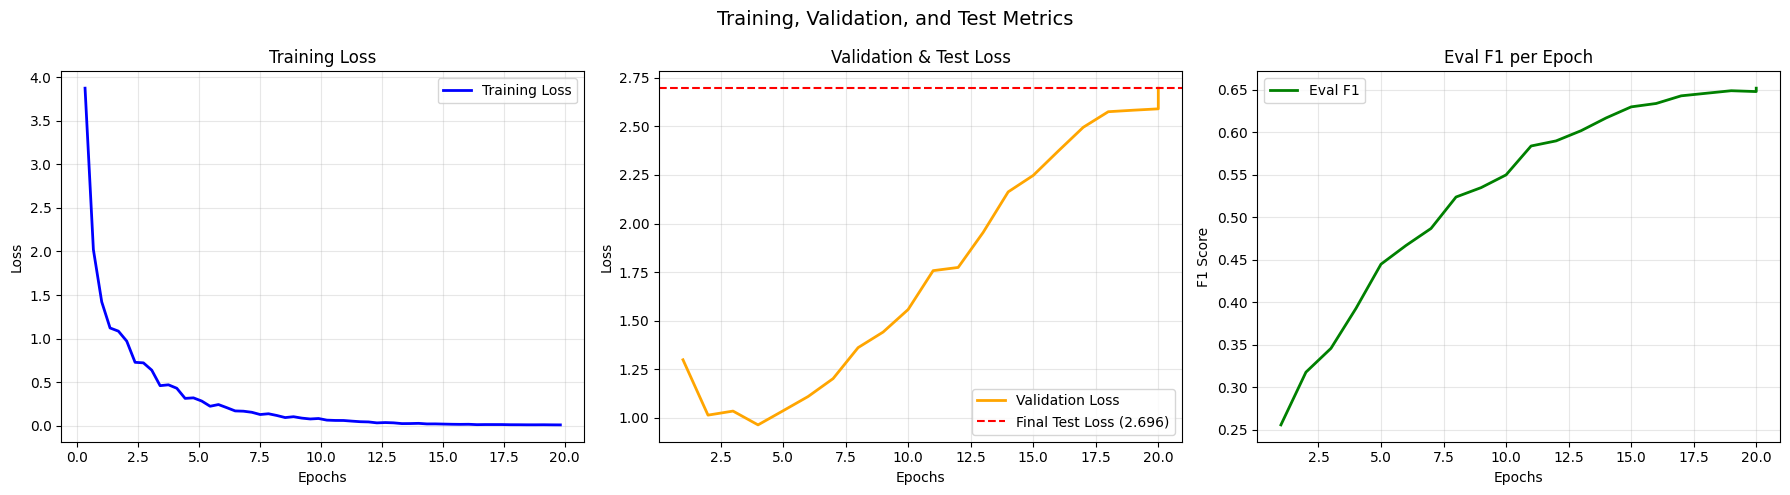

In [17]:
test_results = trainer.evaluate(tokenized_datasets["test"])

print("\n" + "="*40)
print("Test evaluation results")
print("="*40)
for key, value in test_results.items():
    metric_name = key.replace("eval_", "")
    print(f"{metric_name.upper():12}: {value:.4f}")
print("="*40 + "\n")

# plots
history = trainer.state.log_history

train_loss = []
train_steps = []
val_loss = []
val_steps = []
eval_f1 = []
eval_f1_steps = []

for log in history:
    if 'loss' in log and 'epoch' in log:
        train_loss.append(log['loss'])
        train_steps.append(log['epoch'])
    if 'eval_loss' in log and 'epoch' in log:
        val_loss.append(log['eval_loss'])
        val_steps.append(log['epoch'])
    if 'eval_f1' in log and 'epoch' in log:
        eval_f1.append(log['eval_f1'])
        eval_f1_steps.append(log['epoch'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_steps, train_loss, label='Training Loss', color='blue', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_steps, val_loss, label='Validation Loss', color='orange', linewidth=2)
axes[1].axhline(y=test_results['eval_loss'], color='red', linestyle='--',
                label=f"Final Test Loss ({test_results['eval_loss']:.3f})")
axes[1].set_title('Validation & Test Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(eval_f1_steps, eval_f1, label='Eval F1', color='green', linewidth=2)
axes[2].set_title('Eval F1 per Epoch')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training, Validation, and Test Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('ner_loss_curve_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

## Note on Loss Values
The test loss for the weighted model (2.67) is not comparable to the baseline model's test loss (0.45). The `WeightedTrainer` uses a class-weighted cross-entropy loss where rare entity classes receive weights up to 10x. This inflates the absolute loss value.

Model's F1 score (0.650) is a meaningful performance metric in this case

## 6. In depth results analysis
Inspect the worst and the best performing entity classes. This dataset contains some micro entities with representation of 1 data point, identifying these is crucial as the model typically lacks accuracy on these examples due to the lack of quantity, and using data augmentation we could synthesize more data points for the model to learn from.

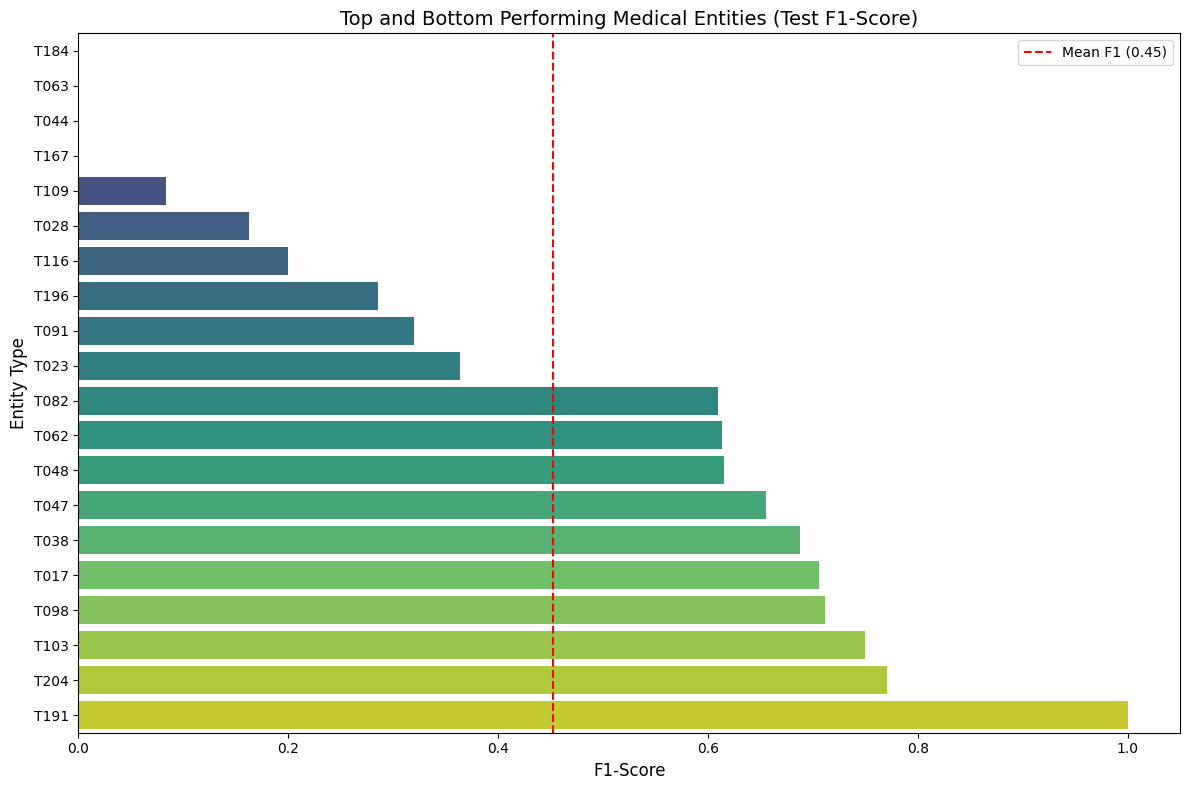


Top 10 Entities by F1-Score:


,Entity_Type,precision,recall,f1-score,support
32,T191,1.000000,1.000000,1.000000,8.0
35,T204,0.736395,0.809346,0.771149,535.0
24,T103,0.714059,0.789405,0.749844,2284.0
23,T098,0.652655,0.782493,0.711701,377.0
2,T017,0.672363,0.742412,0.705653,1219.0
10,T038,0.634288,0.751009,0.687731,2478.0
13,T047,0.612903,0.703704,0.655172,27.0
14,T048,0.444444,1.000000,0.615385,4.0
16,T062,0.548063,0.697080,0.613655,548.0
19,T082,0.555804,0.674797,0.609547,738.0


,Entity_Type,precision,recall,f1-score,support
11,T044,0.000000,0.000000,0.000000,9.0
28,T167,0.000000,0.000000,0.000000,2.0
31,T184,0.000000,0.000000,0.000000,0.0
17,T063,0.000000,0.000000,0.000000,0.0
25,T109,0.052632,0.200000,0.083333,5.0
6,T028,0.093750,0.600000,0.162162,5.0
26,T116,0.214286,0.187500,0.200000,32.0
33,T196,0.166667,1.000000,0.285714,1.0
20,T091,0.333333,0.307692,0.320000,13.0
4,T023,0.307692,0.444444,0.363636,9.0


In [13]:
predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

# per-class classification report
report = classification_report(true_labels, true_predictions, output_dict=True)
df_report = pd.DataFrame(report).transpose().reset_index()
df_report.rename(columns={'index': 'Entity_Type'}, inplace=True)

# filter out useless metrics
class_report = df_report[~df_report['Entity_Type'].isin(['micro avg', 'macro avg', 'weighted avg', 'samples avg'])]

# top 10 v bot 10
top_10 = class_report.sort_values(by='f1-score', ascending=False).head(10)
bottom_10 = class_report.sort_values(by='f1-score', ascending=True).head(10)
plot_data = pd.concat([top_10, bottom_10])
plot_data = plot_data.sort_values('f1-score', ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_data,
    x='f1-score',
    y='Entity_Type',
    hue='Entity_Type',
    palette='viridis',
    legend=False
)
plt.title('Top and Bottom Performing Entities (Test F1-Score)', fontsize=14)
plt.axvline(class_report['f1-score'].mean(), color='red', linestyle='--', label=f"Mean F1 ({class_report['f1-score'].mean():.2f})")
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Entity Type', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('ner_per_entity_f1_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Entities by F1-Score:")
display(top_10)
display(bottom_10)


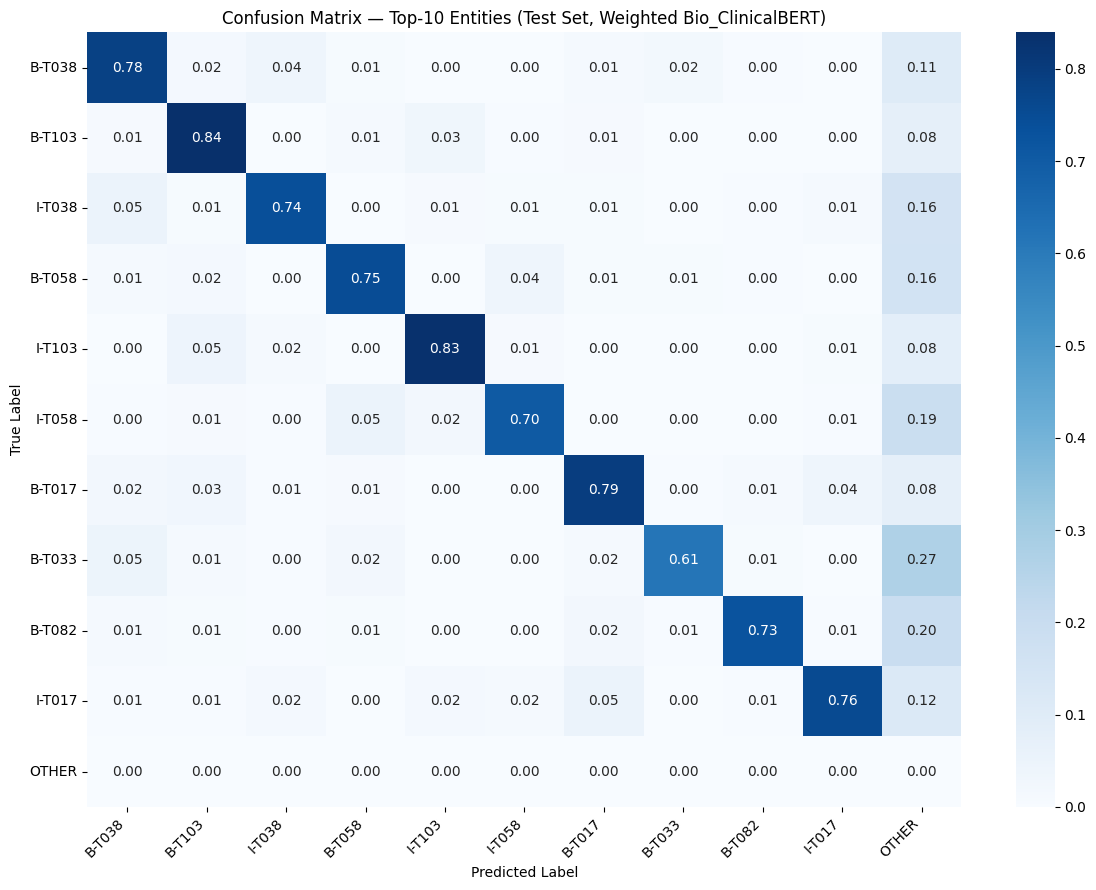

Saved: ner_confusion_matrix_weighted.png


In [18]:
# ------------------------------------------
# Confusion Matrix
# ------------------------------------------
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

flat_true = [label for seq in true_labels for label in seq]
flat_pred = [label for seq in true_predictions for label in seq]

# Get top-10 entity types by support (excluding 'O')
from collections import Counter
entity_counts = Counter(l for l in flat_true if l != 'O')
top_entities = [e for e, _ in entity_counts.most_common(10)]

# Filter to only tokens whose true label is one of top_entities
filtered_true = [t for t, p in zip(flat_true, flat_pred) if t in top_entities]
filtered_pred = [p if p in top_entities else 'OTHER' for t, p in zip(flat_true, flat_pred) if t in top_entities]
labels_cm = top_entities + (['OTHER'] if 'OTHER' in filtered_pred else [])

cm = confusion_matrix(filtered_true, filtered_pred, labels=labels_cm, normalize='true')

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Top-10 Entities (Test Set, Weighted Bio_ClinicalBERT)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('ner_confusion_matrix_weighted.png')
plt.show()
print("Saved: ner_confusion_matrix_weighted.png")


In [15]:
notebook_end_time = time.time()
elapsed = notebook_end_time - notebook_start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total notebook execution time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")


Total notebook execution time: 00:27:21


In [16]:

if PUSH_TO_HUB:
    trainer.push_to_hub(
        commit_message="End of training",
        finetuned_from=config.MODEL_ID,
        dataset=config.DATASET_ID
    )
    tokenizer.push_to_hub(repo_id=config.HUB_REPO_ID)


No files have been modified since last commit. Skipping to prevent empty commit.
